Author: Awab Abedin

Code Red: Detect SWE Burnout


# Intoduction


In modern software development environments, maintaining high productivity while preventing developer burnout is a critical challenge for organizations. Burnout not only reduces individual performance but also leads to missed deadlines, reduced code quality, and disrupts work-life balance. This project aims to build a predictive model that estimates a developer’s productivity and classifies their burnout level based on work patterns, behavioral metrics, and environmental factors. The goal is to enable early intervention by identifying at-risk developers and optimizing team performance.

Link to Dataset: https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples

Github link to Repo: https://github.com/Abedin02/SWE-Burnout-Classification

In [ ]:
# mount to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read an excel file from drive
data = pd.read_csv('/content/drive/MyDrive/developer_burnout_dataset_7000.csv')

In [ ]:
data.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [ ]:
# show the values of caffeine_intake
data['caffeine_intake'].unique()

array([ 2.,  5., nan,  0.,  6.,  4.,  3.,  7.,  1.])

In [ ]:
# show the type of the data
data.dtypes

,0
age,float64
experience_years,float64
daily_work_hours,float64
sleep_hours,float64
caffeine_intake,float64
bugs_per_day,float64
commits_per_day,float64
meetings_per_day,float64
screen_time,float64
exercise_hours,float64


In [ ]:
# create a smaller subset of the dataset of first 50 samples
data_smaller = data.iloc[:30]

# Exploratory Data Analysis

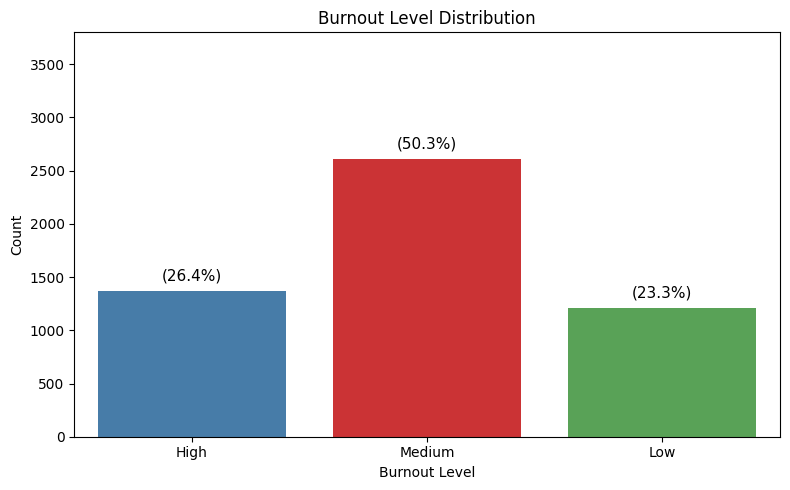

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=data, x='burnout_level', hue='burnout_level',
                   palette='Set1', order=['High', 'Medium', 'Low'], legend=False)

total = len(data)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'({100 * count / total:.1f}%)'
    ax.annotate(f'{percentage}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11,
                xytext=(0, 5), textcoords='offset points')

plt.title('Burnout Level Distribution')
plt.xlabel('Burnout Level')
plt.ylabel('Count')
plt.ylim(0, 3800)
plt.tight_layout()
plt.show()

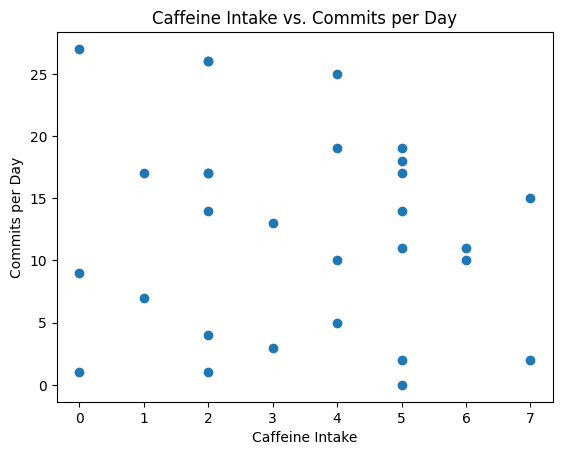

In [ ]:
# create a scatter plot using the smaller dataset
plt.scatter(data_smaller['caffeine_intake'], data_smaller['commits_per_day'])
plt.xlabel('Caffeine Intake')
plt.ylabel('Commits per Day')
plt.title('Caffeine Intake vs. Commits per Day')
plt.show()

There is no visible trend in the scatter plot above which tells us that there is no apparent relation between the amount of caffeine intake against productivity. But the sample used here is too small to make any judgements.

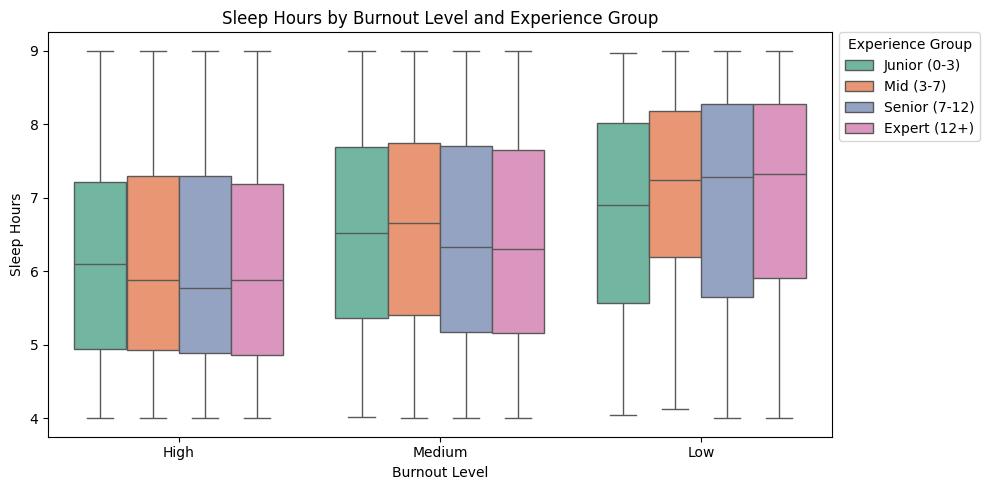

In [ ]:
data['exp_bin'] = pd.cut(data['experience_years'],
                          bins=[0, 3, 7, 12, 20],
                          labels=['Junior (0-3)', 'Mid (3-7)', 'Senior (7-12)', 'Expert (12+)'])

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='burnout_level', y='sleep_hours',
            hue='exp_bin', palette='Set2',
            order=['High', 'Medium', 'Low'])
plt.title('Sleep Hours by Burnout Level and Experience Group')
plt.xlabel('Burnout Level')
plt.ylabel('Sleep Hours')
plt.legend(title='Experience Group', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

From the box plot, it is evident that sleep hours increase as burnout level decreases. Developers with High burnout consistently sleep around 6 hours regardless of their experience level, while those with Low burnout sleep closer to 7–8 hours. This suggests that sleep is one of the strongest indicators of burnout in this dataset.

When looking at experience groups within each burnout level, the four groups: Junior, Mid, Senior, and Expert, show very similar sleep distributions. This tells us that experience alone does not protect a developer from burnout. A senior or expert developer is just as likely to be burned out as a junior developer if their sleep habits are poor.

Overall, the plot strongly suggests that sleep has a direct relationship with burnout level.

# Clean the dataset

In [ ]:
data.isna().sum()

,0
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


140 out of 7000 is only 2% of the dataset. So we can drop the NaN without harming the integrity of the dataset

In [ ]:
# Drop missing values (NaN) from the dataset
data = data.dropna()

In [ ]:
data.isna().sum()

,0
age,0
experience_years,0
daily_work_hours,0
sleep_hours,0
caffeine_intake,0
bugs_per_day,0
commits_per_day,0
meetings_per_day,0
screen_time,0
exercise_hours,0


# Methods

I am going to use **KNN (N=5)**, a supervised machine learning algorithm, to classify burnout level among developers using all the features except burnout level and exp_bin. I need to scale the features so that KNN (a distance based algorithm) is not heavily influenced by a single variable.

In [ ]:
# Show the columns of the dataframe
data.columns

Index(['age', 'experience_years', 'daily_work_hours', 'sleep_hours',
       'caffeine_intake', 'bugs_per_day', 'commits_per_day',
       'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level',
       'burnout_level', 'exp_bin'],
      dtype='object')

Accuracy: 0.8346

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.80      0.82       299
         Low       0.85      0.83      0.84       225
      Medium       0.82      0.85      0.84       516

    accuracy                           0.83      1040
   macro avg       0.84      0.83      0.83      1040
weighted avg       0.84      0.83      0.83      1040



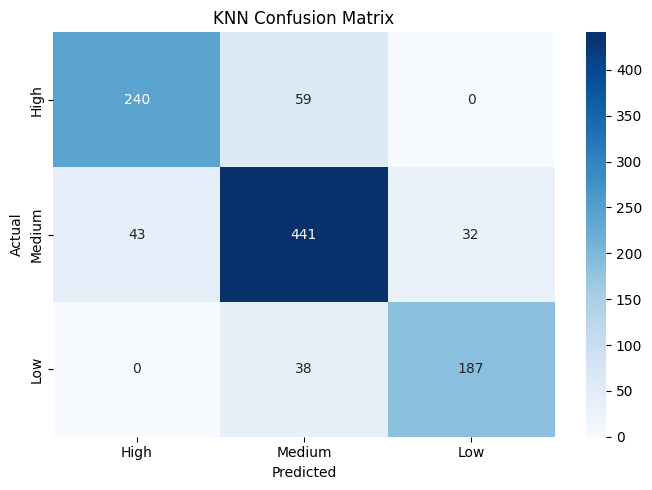

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Select all the feature variables and set the target variable
features = [col for col in data.columns if col not in ['burnout_level' 'exp_bin']]
X = data[features]
y = data['burnout_level']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (KNN is a distance based algorithm, so scaling is crucial)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN model with N = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)



# Predict
y_pred = knn.predict(X_test_scaled)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
order = ['High', 'Medium', 'Low']

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels=order),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=order,
            yticklabels=order)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


I will tune the parameter **K** to find the optimal number of neighbors during classification.

Visualize Error rates against varrying K

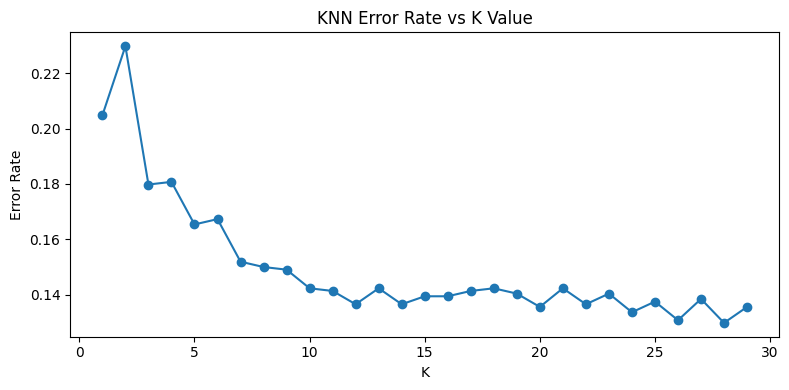

In [ ]:
# Find best k
error_rates = []
# Check for K in range 1 to 30 and store the error rate for each in a list
for k in range(1, 30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    error_rates.append(1 - accuracy_score(y_test, knn_k.predict(X_test_scaled)))

# Visualize error rate against K neightbors
plt.figure(figsize=(8, 4))
plt.plot(range(1, 30), error_rates, marker='o')
plt.title('KNN Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.tight_layout()
plt.show()


Get the K corresponding to the lowest error rate

In [ ]:
# Best K
best_k = error_rates.index(min(error_rates)) + 1
print(f"The optimal K is: {best_k}")

The optimal K is: 28


In [ ]:
# Evaluation metrics for optimal K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)
print("Evaluating the KNN model using optimal number of K =", best_k)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Evaluating the KNN model using optimal number of K = 28

Accuracy: 0.8702

Classification Report:
              precision    recall  f1-score   support

        High       0.91      0.80      0.85       299
         Low       0.91      0.85      0.88       225
      Medium       0.84      0.92      0.88       516

    accuracy                           0.87      1040
   macro avg       0.89      0.86      0.87      1040
weighted avg       0.87      0.87      0.87      1040



I am going to compare KNN with another supervised learning algorithm, **Random Forest**. Random Forests perform well with non-linear decision boundaries like the one present in the dataset. Random Forests are a tree based algorithm so no scaling is required. Burnout level and exp_bin are left out during training.



Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       299
         Low       1.00      1.00      1.00       225
      Medium       1.00      1.00      1.00       516

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



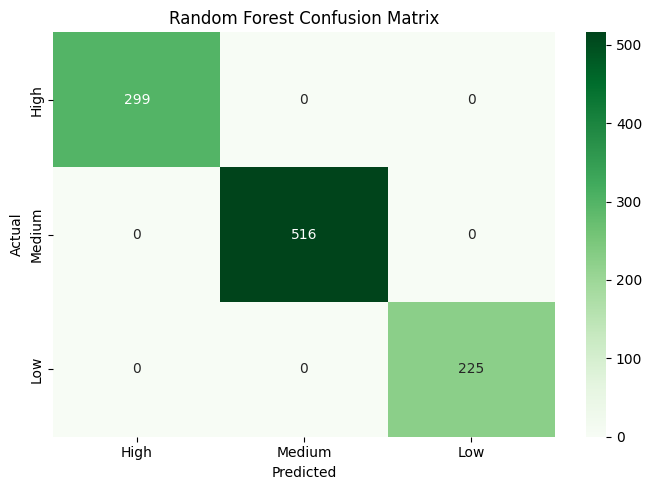

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Features and target
# Use all the features in the dataset
features = [col for col in data.columns if col not in ['burnout_level', 'exp_bin']]
X = data[features]
y = data['burnout_level']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest (n_estimators = 100, which means 100 trees are built each with a random subset of the dataset)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict (All 100 trees vote and the majority determines the prediction class)
y_pred = rf.predict(X_test)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
order = ['High', 'Medium', 'Low']
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels=order),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=order,
            yticklabels=order)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

A 100% accuracy is a red flag, this is almost certainly overfitting. I will visualize the feature relevance to find which variable has the highest contribution to the prediction.

             Feature  Importance
10      stress_level    0.744654
2   daily_work_hours    0.066901
5       bugs_per_day    0.059941
8        screen_time    0.043340
7   meetings_per_day    0.032252
3        sleep_hours    0.019541
9     exercise_hours    0.009270
4    caffeine_intake    0.009239
6    commits_per_day    0.005170
0                age    0.005151
1   experience_years    0.004541


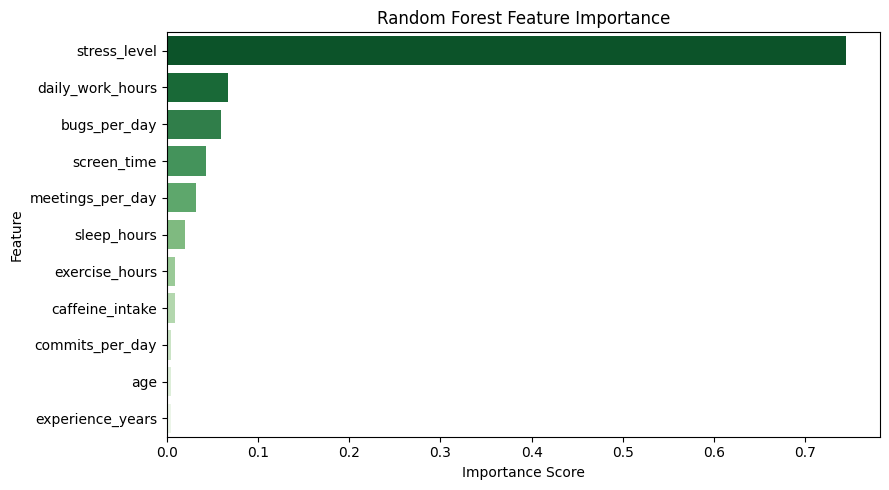

In [ ]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            hue='Feature', palette='Greens_r', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Stress level has a direct correlation to Burnout Level, which is intuitive. The Random Forest is essentially 'cheating' by using Stress level to perfectly predict Burnout Level. To address this issue, I am going to run another Random Forest model - leaving out stress level, burnout level and exp_bin during training.

Accuracy: 0.7644

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.65      0.72       299
         Low       0.84      0.72      0.78       225
      Medium       0.72      0.85      0.78       516

    accuracy                           0.76      1040
   macro avg       0.79      0.74      0.76      1040
weighted avg       0.77      0.76      0.76      1040



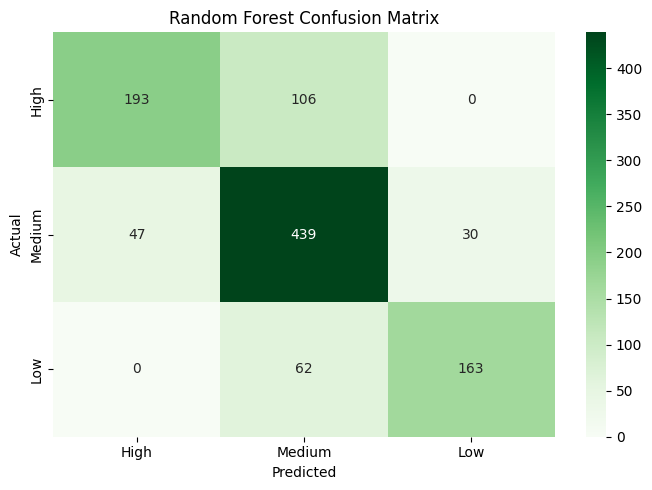

In [ ]:
# Features and target
# Use all the features in the dataset
features = [col for col in data.columns if col not in ['burnout_level', 'exp_bin', 'stress_level']]
X = data[features]
y = data['burnout_level']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest (n_estimators = 100, which means 100 trees are built each with a random subset of the dataset)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict (All 100 trees vote and the majority determines the prediction class)
y_pred = rf.predict(X_test)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
order = ['High', 'Medium', 'Low']
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels=order),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=order,
            yticklabels=order)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Random Forest** performs worse than the **KNN** model.

I am going to tune the hyperparameter, **n_estimators**, in an attempt to get better results. N_estimators is the number of decision trees used to calculate the final prediction.

n_estimators=  10 | Accuracy: 0.7308
n_estimators=  20 | Accuracy: 0.7481
n_estimators=  30 | Accuracy: 0.7567
n_estimators=  40 | Accuracy: 0.7615
n_estimators=  50 | Accuracy: 0.7644
n_estimators=  60 | Accuracy: 0.7712
n_estimators=  70 | Accuracy: 0.7683
n_estimators=  80 | Accuracy: 0.7635
n_estimators=  90 | Accuracy: 0.7673
n_estimators= 100 | Accuracy: 0.7644
n_estimators= 110 | Accuracy: 0.7692
n_estimators= 120 | Accuracy: 0.7654
n_estimators= 130 | Accuracy: 0.7615
n_estimators= 140 | Accuracy: 0.7625
n_estimators= 150 | Accuracy: 0.7615
n_estimators= 160 | Accuracy: 0.7615
n_estimators= 170 | Accuracy: 0.7596
n_estimators= 180 | Accuracy: 0.7587
n_estimators= 190 | Accuracy: 0.7577
n_estimators= 200 | Accuracy: 0.7587

Best n_estimators: 60 with Accuracy: 0.7712


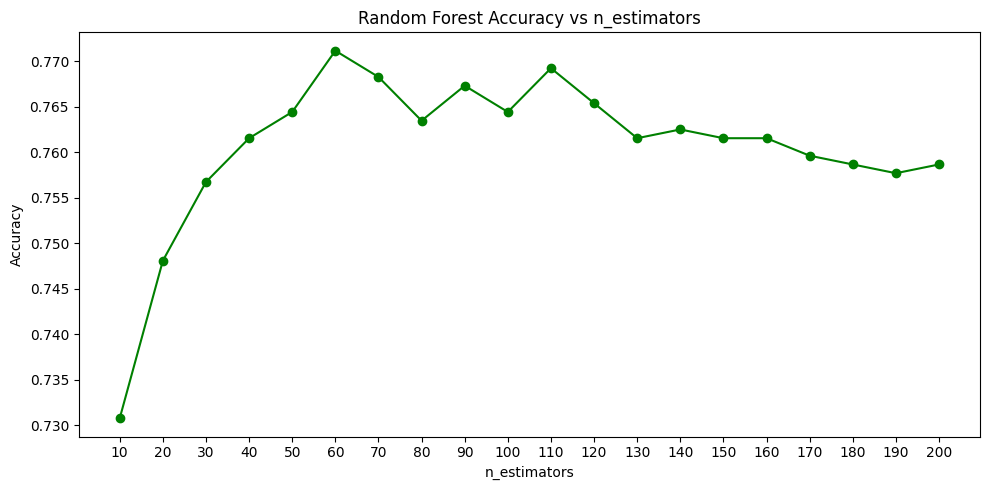

In [ ]:
def tune_n_estimators(X_train, X_test, y_train, y_test, estimator_range=range(10, 201, 10)):
    results = []

    for n in estimator_range:
        rf_tuned = RandomForestClassifier(n_estimators=n, random_state=42)
        rf_tuned.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf_tuned.predict(X_test))
        results.append({'n_estimators': n, 'accuracy': acc})
        print(f"n_estimators={n:>4} | Accuracy: {acc:.4f}")

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df['accuracy'].idxmax()]
    print(f"\nBest n_estimators: {int(best['n_estimators'])} with Accuracy: {best['accuracy']:.4f}")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(results_df['n_estimators'], results_df['accuracy'], marker='o', color='green')
    plt.title('Random Forest Accuracy vs n_estimators')
    plt.xlabel('n_estimators')
    plt.ylabel('Accuracy')
    plt.xticks(list(estimator_range))
    plt.tight_layout()
    plt.show()

    return int(best['n_estimators'])

# Run it
best_n = tune_n_estimators(X_train, X_test, y_train, y_test)

The accuracy plateaus at n_estimators = 60 with an accuracy score of 0.7712 for Random Forest.


I will visualize feature importance to see which variables contribute to prediction

            Feature  Importance
5      bugs_per_day    0.190710
2  daily_work_hours    0.182923
8       screen_time    0.126525
7  meetings_per_day    0.108064
3       sleep_hours    0.106948
9    exercise_hours    0.074486
4   caffeine_intake    0.057174
6   commits_per_day    0.051594
1  experience_years    0.051312
0               age    0.050263


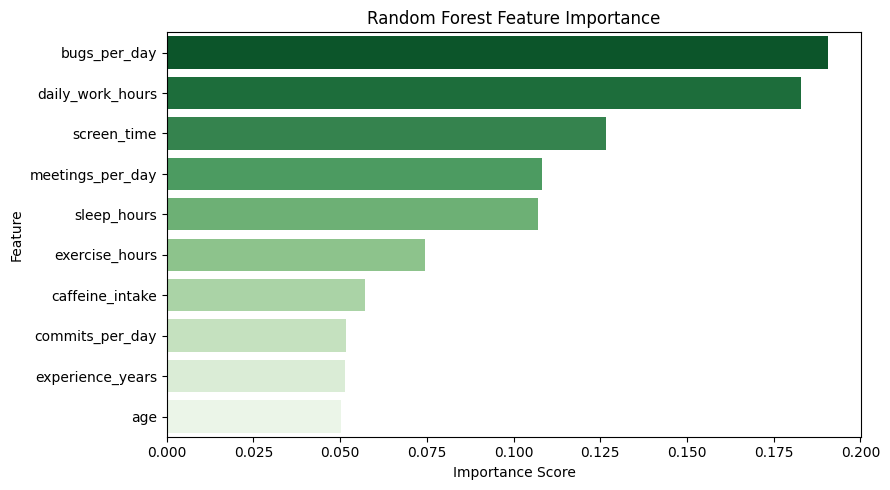

In [ ]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            hue='Feature', palette='Greens_r', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The Random Forest feature importance plot reveals that bugs_per_day and daily_work_hours are the two strongest predictors of burnout, when stress level is left out

# Conclusion

This project set out to build a machine learning model capable of predicting developer burnout levels using behavioral and work pattern data. Two classification algorithms were explored: K-Nearest Neighbors (KNN) and Random Forest.

Hyperparameter tuning was performed on both models. For KNN, the optimal value of K was found to be 28, yielding an accuracy of 87.02%. For Random Forest, the accuracy plateaued at n_estimators = 60, achieving an accuracy of 77.12%, notably lower than KNN despite Random Forest generally being the stronger algorithm on non-linear datasets.

Based on these results, the KNN model with K = 28 is the recommended model for this dataset.

Future work could explore additional algorithms such as Gradient Boosting or XGBoost, incorporate more features such as team size, remote work status, and personal factors, and address the class imbalance in the dataset.

The project may be shared as a referance